# 01 – Data cleaning & exploratory analysis

**Dataset:** [Online Retail II (UCI)](https://archive.ics.uci.edu/dataset/502/online+retail+ii): all transactions of a UK-based online retailer selling giftware, mostly to wholesalers, from **Dec. 2009 to Dec. 2011** (~1.07M invoice lines).

**Goal of this notebook:**
1. Clean the raw data and measure each data quality issue.
2. Understand the sales: trend, seasonality, weekly pattern, countries, products, customers.
3. Draw the conclusions that will drive the forecasting model (notebook 02).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import data_prep as dp
import plot_style as ps

ps.apply()
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load and clean the data

In [2]:
raw = dp.load_raw()
print(f"{len(raw):,} raw lines, columns: {list(raw.columns)}")
raw.head()

1,067,371 raw lines, columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [3]:
sales, quality = dp.clean(raw)
quality["share_of_raw_%"] = (quality["rows_removed"] / len(raw) * 100).round(2)
quality

,step,rows_removed,rows_left,share_of_raw_%
0,Raw data,0,1067371,0.00
1,Exact duplicates,34335,1033036,3.22
2,Cancellation lines (invoice 'C...'),19104,1013932,1.79
3,Purchases matched by a later cancellation,7067,1006865,0.66
4,Bad-debt adjustments (invoice 'A...'),6,1006859,0.00
5,"Non-product lines (postage, fees, discounts, v...",4409,1002450,0.41
6,Quantity <= 0 or price <= 0,5962,996488,0.56


**Data quality findings**
- **3.2%** of the raw lines are exact duplicates.
- **~19k cancellation lines**, plus **~7k purchases that were cancelled afterwards** (matched on customer, product and quantity). Without this step, a single 80,995-unit order cancelled a few minutes later would create a huge fake peak.
- Postage, fees, manual adjustments and gift vouchers are not product sales and are removed.
- About **23% of the lines have no customer ID**. They are kept for revenue analysis (they are real sales) but cannot be used for customer analysis.

In [4]:
missing_customer = raw["CustomerID"].isna().mean()
print(f"Lines without customer ID: {missing_customer:.1%}")
print(f"Clean product lines kept: {len(sales):,} ({len(sales) / len(raw):.1%} of raw)")

Lines without customer ID: 22.8%
Clean product lines kept: 996,488 (93.4% of raw)


## 2. Key figures

In [5]:
kpis = pd.Series({
    "Period": f"{sales['Date'].min():%d %b %Y} – {sales['Date'].max():%d %b %Y}",
    "Revenue": ps.money(sales["Revenue"].sum()),
    "Orders (invoices)": f"{sales['Invoice'].nunique():,}",
    "Identified customers": f"{sales['CustomerID'].nunique():,}",
    "Products": f"{sales['StockCode'].nunique():,}",
    "Countries": sales["Country"].nunique(),
    "Average order value": ps.money(sales.groupby("Invoice")["Revenue"].sum().mean()),
})
kpis.to_frame("value")

,value
Period,01 Dec 2009 – 09 Dec 2011
Revenue,£19.1M
Orders (invoices),"39,227"
Identified customers,"5,833"
Products,"4,886"
Countries,43
Average order value,£486


## 3. Monthly revenue: strong year-end seasonality

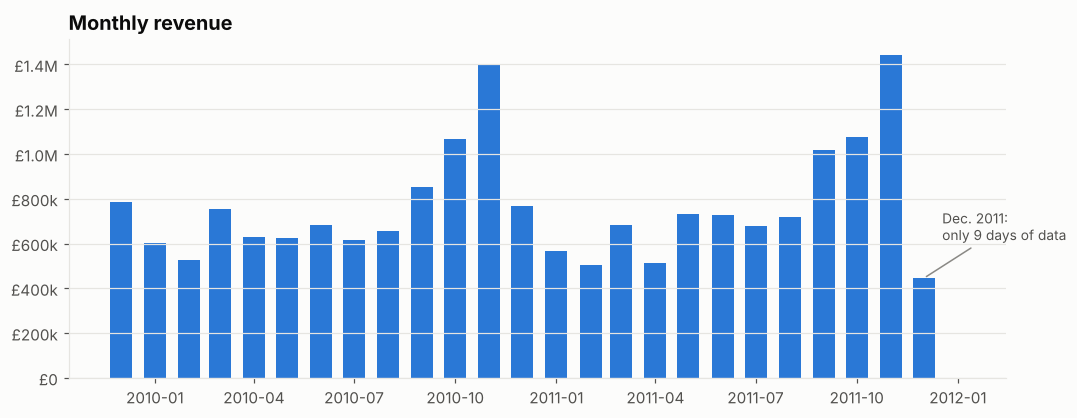

Jan–Nov 2011 vs Jan–Nov 2010: +2.9%
Sept–Nov share of yearly revenue (2010): 36%


In [6]:
monthly = sales.groupby(sales["Date"].dt.to_period("M"))["Revenue"].sum()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly.index, monthly.values, width=20, color=ps.BLUE)
ax.yaxis.set_major_formatter(ps.MONEY)
ax.set_title("Monthly revenue")
ax.annotate("Dec. 2011:\nonly 9 days of data", xy=(monthly.index[-1], monthly.iloc[-1]),
            xytext=(12, 25), textcoords="offset points", color=ps.TEXT_2, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=ps.GRAY))
ax.set_xlim(right=monthly.index[-1] + pd.Timedelta(days=75))
fig.savefig(FIG / "monthly_revenue.png")
plt.show()

yoy = monthly["2011-01":"2011-11"].sum() / monthly["2010-01":"2010-11"].sum() - 1
print(f"Jan–Nov 2011 vs Jan–Nov 2010: {yoy:+.1%}")
print(f"Sept–Nov share of yearly revenue (2010): {monthly['2010-09':'2010-11'].sum() / monthly['2010'].sum():.0%}")

**Insight:** sales are stable from January to August, then rise sharply from September to a **peak in November** (Christmas orders from wholesalers). November is about **2× a typical month**. Any forecasting model must capture this yearly seasonality.

## 4. Weekly and daily patterns

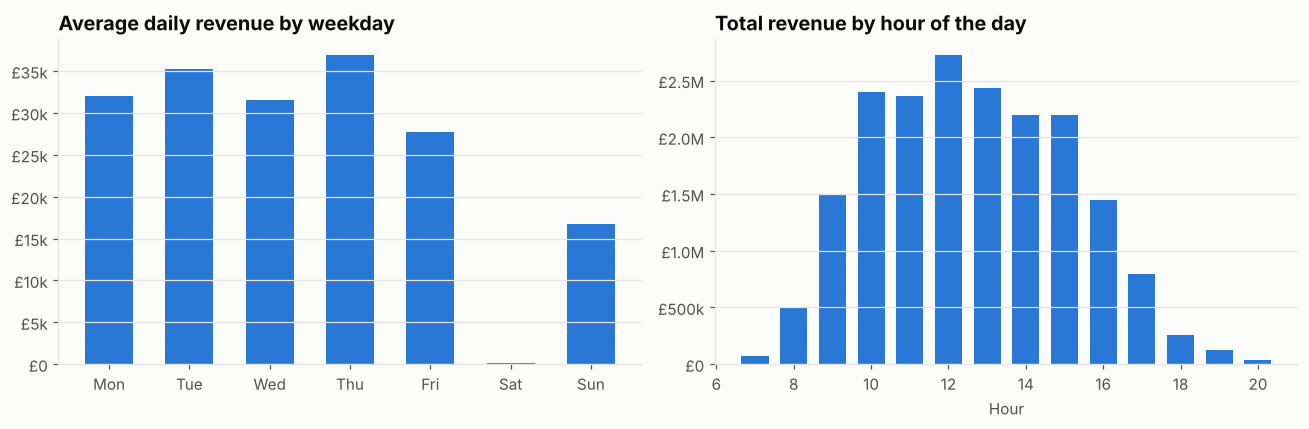

,avg_daily_revenue
date,
Monday,"31,980.38"
Tuesday,"35,273.86"
Wednesday,"31,512.63"
Thursday,"36,928.50"
Friday,"27,728.10"
Saturday,90.65
Sunday,"16,784.28"


In [7]:
daily = dp.daily_sales(sales)
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = daily.groupby(daily["date"].dt.day_name())["revenue"].mean().reindex(order)

hourly = sales.groupby(sales["InvoiceDate"].dt.hour)["Revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([d[:3] for d in order], by_dow.values, color=ps.BLUE, width=0.6)
axes[0].yaxis.set_major_formatter(ps.MONEY)
axes[0].set_title("Average daily revenue by weekday")
axes[1].bar(hourly.index, hourly.values, color=ps.BLUE, width=0.7)
axes[1].yaxis.set_major_formatter(ps.MONEY)
axes[1].set_title("Total revenue by hour of the day")
axes[1].set_xlabel("Hour")
fig.tight_layout()
fig.savefig(FIG / "weekday_hour.png")
plt.show()
by_dow.to_frame("avg_daily_revenue")

**Insights**
- **No sales on Saturdays**: the business does not process orders that day. Sunday is lower than weekdays, Thursday is the strongest day.
- Orders are placed during **office hours (7am–8pm), peaking around noon**: a B2B pattern (wholesalers), not a consumer one.
- The weekday effect is strong, so the model needs **day-of-week features**.

## 5. Countries

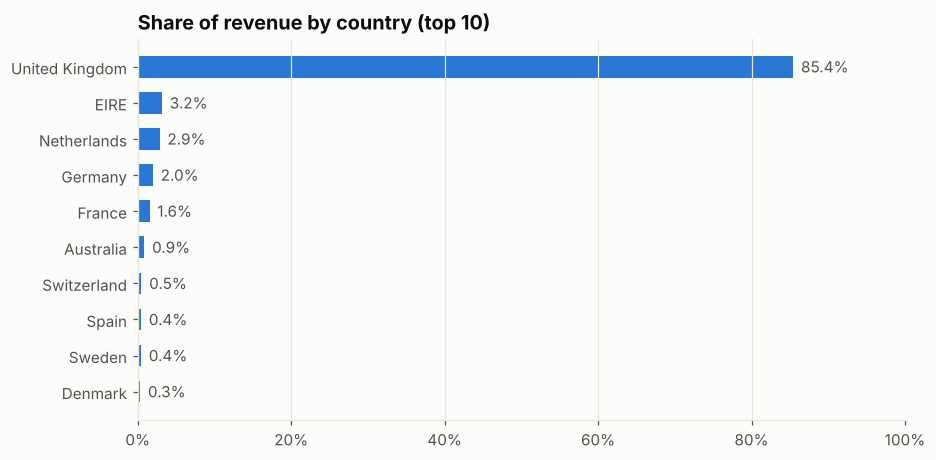

United Kingdom: 85.4% of revenue


In [8]:
country = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
share = country / country.sum()
top = share.head(10)[::-1]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top.index, top.values, color=ps.BLUE, height=0.6)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for y, v in enumerate(top.values):
    ax.text(v + 0.01, y, f"{v:.1%}", va="center", color=ps.TEXT_2)
ax.set_xlim(0, 1)
ax.set_title("Share of revenue by country (top 10)")
fig.savefig(FIG / "countries.png")
plt.show()
print(f"United Kingdom: {share['United Kingdom']:.1%} of revenue")

**Insight:** the **United Kingdom represents ~85% of revenue**. The next markets (Ireland, Netherlands, Germany, France) weigh 1.5–3% each. The forecast will be built on total revenue, and the app will allow filtering by country.

## 6. Products

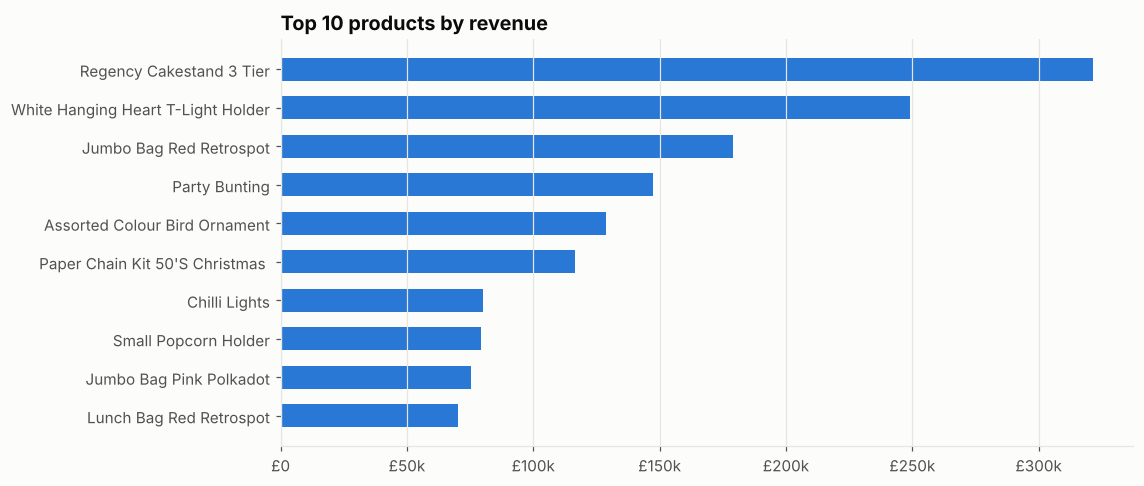

1,050 products out of 4,886 (21%) make 80% of revenue


In [9]:
prod = (sales.groupby(["StockCode"])
        .agg(revenue=("Revenue", "sum"), units=("Quantity", "sum"),
             description=("Description", lambda s: s.mode().iat[0] if not s.mode().empty else ""))
        .sort_values("revenue", ascending=False))
top_p = prod.head(10)[::-1]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(top_p["description"].str.title().str.slice(0, 38), top_p["revenue"], color=ps.BLUE, height=0.6)
ax.xaxis.set_major_formatter(ps.MONEY)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Top 10 products by revenue")
fig.savefig(FIG / "top_products.png")
plt.show()

cum = prod["revenue"].cumsum() / prod["revenue"].sum()
n80 = (cum <= 0.8).sum() + 1
print(f"{n80:,} products out of {len(prod):,} ({n80 / len(prod):.0%}) make 80% of revenue")

**Insight:** the catalogue is very wide (~4,900 products) but revenue is concentrated: about **a fifth of the products make 80% of revenue** (Pareto principle). Forecasting each product separately would be noisy; forecasting **total daily revenue** is the right level for a first model.

## 7. Customers

In [10]:
cust = sales.dropna(subset=["CustomerID"]).groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
top20 = cust.head(int(len(cust) * 0.2)).sum() / cust.sum()
orders_per_cust = sales.dropna(subset=["CustomerID"]).groupby("CustomerID")["Invoice"].nunique()
print(f"Identified customers: {len(cust):,}")
print(f"Top 20% customers = {top20:.0%} of identified revenue")
print(f"Customers who ordered only once: {(orders_per_cust == 1).mean():.0%}")

Identified customers: 5,833
Top 20% customers = 77% of identified revenue
Customers who ordered only once: 28%


**Insight:** the top 20% of customers generate the large majority of revenue, while a sizeable share orders only once. This supports a later **customer segmentation (RFM)** or retention analysis, out of scope for this forecasting project.

## 8. The series to forecast: daily revenue

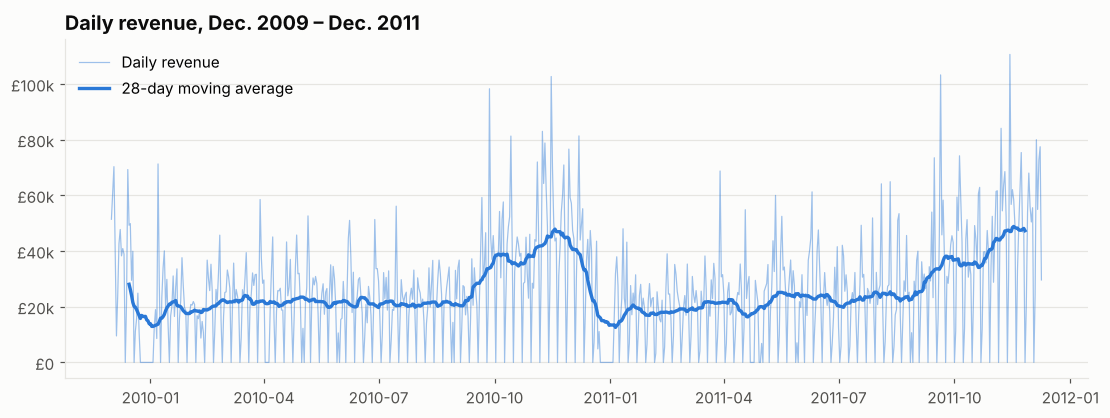

Days in calendar: 739, days with zero sales: 135 (Saturdays + Christmas closure)
Average daily revenue (open days): £32k


In [11]:
d = daily.set_index("date")["revenue"]
roll = d.rolling(28, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d.index, d.values, color=ps.BLUE, linewidth=0.8, alpha=0.45, label="Daily revenue")
ax.plot(roll.index, roll.values, color=ps.BLUE, linewidth=2.2, label="28-day moving average")
ax.yaxis.set_major_formatter(ps.MONEY)
ax.set_title("Daily revenue, Dec. 2009 – Dec. 2011")
ax.legend(loc="upper left")
fig.savefig(FIG / "daily_revenue.png")
plt.show()

print(f"Days in calendar: {len(d)}, days with zero sales: {(d == 0).sum()} (Saturdays + Christmas closure)")
print(f"Average daily revenue (open days): {ps.money(d[d > 0].mean())}")

## 9. Conclusions for the forecasting model

| Finding | Consequence for the model |
|---|---|
| Strong yearly seasonality (Sept–Nov peak) | Calendar features: month, week of year, day of year; lags of 1 year are not usable (only 2 years of data) |
| Strong weekday effect, no Saturday sales | Day-of-week features; Saturdays and closure days predicted as 0 |
| Christmas closure (~24 Dec – 3 Jan) | Closure / holiday flags (UK bank holidays) |
| Noisy daily series | Lags and rolling means (7, 14, 28 days) to capture the recent level |
| UK = 85% of revenue | Forecast total revenue; country filter in the app |

**Evaluation plan:** train on Dec. 2009 – Aug. 2011, test on **Sept – Dec. 2011** (the hardest and most business-critical period: the Christmas peak). Compare a naive baseline with linear regression, Random Forest and XGBoost using **MAE, RMSE and MAPE** (on open days).

In [12]:
daily.to_csv(ROOT / "data" / "processed" / "daily_sales.csv", index=False)
quality.to_csv(ROOT / "reports" / "data_quality.csv", index=False)
print("Saved processed data and data quality report.")

Saved processed data and data quality report.
